In [1]:
import xgboost
print(f"XGBoost version: {xgboost.__version__}")

XGBoost version: 3.1.2


In [2]:
import pandas as pd

In [ ]:
from massive import RESTClient
import os
polygon_api_key = os.getenv("POLYGON_API_KEY")
client = RESTClient(polygon_api_key)

aggs = []
for a in client.list_aggs(
    "SPY",
    1,
    "minute",
    "2020-01-01",
    "2025-12-31",
    adjusted="true",
    sort="asc",
    limit=50000,
):
    aggs.append(a)

In [4]:
feats = [
        'seconds_since_open', 
       'atr5_over_atrOpen', 'atr_30_minus_120',
       # Interaction features
       'vwap_std_x_atr', 'time_x_vol_frac', 'atr5_over_atr30',
       'atr60_over_atr120',
       'atr5_over_max', 
       'vwap_range_x_std']

In [5]:
import numpy as np

In [6]:
# ===== HELPER FUNCTIONS =====

def calculate_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    Calculate the Relative Strength Index (RSI).
    
    RSI = 100 - (100 / (1 + RS))
    where RS = Average Gain / Average Loss
    
    Args:
        series: Price series (typically close prices)
        period: Lookback period (default: 14)
    
    Returns:
        Series with RSI values (0-100)
    """
    # Calculate price changes
    delta = series.diff()
    
    # Separate gains and losses
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # Calculate exponential moving average of gains and losses
    avg_gain = gain.ewm(span=period, adjust=False).mean()
    avg_loss = loss.ewm(span=period, adjust=False).mean()
    
    # Calculate RS and RSI
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi


def compute_atr(df: pd.DataFrame, n: int = 30) -> pd.Series:
    """
    Calculate Average True Range (ATR) normalized by VWAP - measures market volatility.
    Higher ATR indicates higher volatility; normalization allows comparison across price levels.
    
    Args:
        df: DataFrame with columns 'h' (high), 'l' (low), 'c' (close), 'vwap'
        n: Rolling window size for averaging true range
    
    Returns:
        Series of normalized ATR values
    """
    prev_c = df['c'].shift(1)
    tr = np.maximum(df['h'] - df['l'], np.maximum((df['h'] - prev_c).abs(), (df['l'] - prev_c).abs())) / df['vwap']
    return tr.rolling(n, min_periods=5).mean()


def true_range(df: pd.DataFrame) -> pd.Series:
    """
    Calculate True Range - the greatest of: (high-low), |high-prev_close|, or |low-prev_close|.
    Captures volatility including gaps between trading periods.
    
    Args:
        df: DataFrame with columns 'h' (high), 'l' (low), 'c' (close)
    
    Returns:
        Series of true range values
    """
    prev_c = df['c'].shift(1)
    tr = np.maximum(df['h'] - df['l'], np.maximum((df['h'] - prev_c).abs(), (df['l'] - prev_c).abs()))
    return tr


# ===== DATA PREPROCESSING =====

def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare raw OHLCV data: filter to market hours, sort by date/time, and calculate VWAP.
    
    Args:
        df: Raw DataFrame with OHLCV data
    
    Returns:
        Preprocessed DataFrame with VWAP and time features
    """
    import datetime
    
    # Standardize date column and sort
    df['date'] = pd.to_datetime(df['date']).dt.date
    df = df.sort_values(['date', 'datetime']).reset_index(drop=True)
    
    # Filter to regular market hours (9:30 AM - 4:00 PM ET)
    df = df[(df['datetime'].dt.time >= datetime.time(9, 30)) & 
            (df['datetime'].dt.time <= datetime.time(16, 0))]
    

    # VWAP with daily reset
    pv = (df['c'] * df['v']).groupby(df['date']).cumsum()
    vv = df['v'].groupby(df['date']).cumsum()

    df['vwap'] = pv / vv
        
    # Calculate seconds since market open for intraday timing features
    for k, v in df.groupby('date'):
        v = v.sort_values('ts_epoch')
        df.loc[v.index, 'open_ts_epoch'] = v['ts_epoch'].iloc[0]
    df['seconds_since_open'] = df['ts_epoch'] - df['open_ts_epoch']
    
    return df


# ===== FEATURE ENGINEERING FUNCTIONS =====



def create_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create momentum-based features including RSI.
    RSI helps identify overbought/oversold conditions and potential reversals.
    
    Args:
        df: DataFrame with price data (must have 'c' column for close price)
    
    Returns:
        DataFrame with added RSI column
    """
    df = df.copy()
    df['RSI'] = calculate_rsi(df['c'], period=14)
    return df


def create_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create volatility features using ATR across multiple timeframes.
    Multi-timeframe ATR captures both short-term noise and longer-term regime changes.
    
    Args:
        df: DataFrame with OHLCV data grouped by date
    
    Returns:
        DataFrame with ATR features (5, 30, 60, 120 minute windows)
    """
    # ATR across different time windows to capture multi-scale volatility
    for period in [5, 30, 60, 120]:
        df[f'atr{period}'] = (
            df.groupby('date', group_keys=False)
            .apply(lambda x: compute_atr(x, period))
        )
    
    # Intraday true range normalized by current price
    df['tr'] = true_range(df) / df['c']
    
    # Expanding average of true range from market open (realized volatility so far)
    df['atr_from_open'] = (
        df.groupby('date')['tr']
        .expanding()
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Track maximum ATR5 seen so far today (for relative volatility)
    df['atr5_max_today'] = df.groupby('date')['atr5'].cummax()
    
    return df


def create_volatility_ratio_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create ratio features comparing volatility across timeframes.
    Ratios help identify volatility expansion/contraction and regime changes.
    
    Features:
    - atr5_over_max: Current volatility vs today's max (mean reversion signal)
    - atr5_over_atrOpen: Short-term vol vs realized vol (acceleration detector)
    - atr_30_minus_120: Medium vs long-term vol difference (trend strength)
    - atr60_over_atr120: Hour-scale vs 2-hour scale volatility ratio
    - atr5_over_atr30: Very short vs short-term volatility ratio
    
    Args:
        df: DataFrame with ATR features already calculated
    
    Returns:
        DataFrame with volatility ratio features
    """
    df['atr5_over_max'] = df['atr5'] / df['atr5_max_today']
    df['atr5_over_atrOpen'] = df['atr5'] / df['atr_from_open']
    df['atr_30_minus_120'] = df['atr30'] - df['atr120']
    df['atr60_over_atr120'] = df['atr60'] / df['atr120']
    df['atr5_over_atr30'] = df['atr5'] / df['atr30']
    
    return df


def create_vwap_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create VWAP distance and statistical features.
    VWAP distance helps identify price extremes and potential mean reversion opportunities.
    
    Features:
    - vwap_dist: Normalized distance from VWAP
    - Rolling statistics (std, max, min) over multiple windows
    - vwap_range: Intraday range of VWAP distance (volatility proxy)
    
    Args:
        df: DataFrame with VWAP already calculated
    
    Returns:
        DataFrame with VWAP distance features
    """
    # Normalized distance from VWAP (positive = above VWAP, negative = below)
    df['vwap_dist'] = (df['c'] - df['vwap']) / df['c']
    
    # Rolling statistics of VWAP distance across multiple windows
    for window in [5, 20, 30]:    
        df[f'vwap_dist_rolling_std_{window}'] = df.groupby('date')['vwap_dist'].transform(
            lambda x: x.rolling(window).std()
        )
        df[f'vwap_dist_rolling_max_{window}'] = df.groupby('date')['vwap_dist'].transform(
            lambda x: x.rolling(window).max()
        )
        df[f'vwap_dist_rolling_min_{window}'] = df.groupby('date')['vwap_dist'].transform(
            lambda x: x.rolling(window).min()
        )
    
    # Range of VWAP distance over 30-minute window (daily excursion)
    df['vwap_range'] = df['vwap_dist_rolling_max_30'] - df['vwap_dist_rolling_min_30']
    
    return df


def create_volume_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create volume-based features for understanding intraday trading activity patterns.
    
    Features:
    - cum_vol_frac: Recent volume as fraction of total daily volume so far
    
    Args:
        df: DataFrame with volume data
    
    Returns:
        DataFrame with volume features
    """
    # Recent 5-minute volume as fraction of cumulative daily volume
    # High values indicate acceleration of trading activity
    df['cum_vol_frac'] = (
        df.groupby('date')['v'].rolling(5).sum().reset_index(0, drop=True) /
        df.groupby('date')['v'].cumsum()
    )
    
    return df


def create_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create interaction features combining multiple dimensions (time, volatility, VWAP).
    Interactions can capture non-linear relationships and regime-dependent behavior.
    
    Features:
    - time_x_vol_frac: Time of day weighted by volume activity
    - vwap_range_x_std: VWAP range amplified by short-term volatility
    - vwap_std_x_atr: VWAP volatility combined with relative ATR (complex regime indicator)
    
    Args:
        df: DataFrame with base features already created
    
    Returns:
        DataFrame with interaction features
    """
    # Time of day weighted by volume pattern (identifies unusual volume timing)
    df['time_x_vol_frac'] = df['seconds_since_open'] * df['cum_vol_frac']
    
    # VWAP range amplified by short-term standard deviation
    df['vwap_range_x_std'] = df['vwap_range'] * df['vwap_dist_rolling_std_5']
    
    # VWAP volatility scaled by relative ATR (combines price position instability with volatility regime)
    df['vwap_std_x_atr'] = df['vwap_dist_rolling_std_20'] * df['atr5_over_atrOpen']
    
    return df


# ===== MAIN FEATURE PIPELINE =====

# Preprocess data
spy_df = preprocess_dataframe(spy_df)

# Create all feature groups
spy_df = create_momentum_features(spy_df)
spy_df = create_volatility_features(spy_df)
spy_df = create_volatility_ratio_features(spy_df)
spy_df = create_vwap_features(spy_df)
spy_df = create_volume_features(spy_df)
spy_df = create_interaction_features(spy_df)


/tmp/ipykernel_19999/2030750753.py:141: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_atr(x, period))
/tmp/ipykernel_19999/2030750753.py:141: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_atr(x, period))
/tmp/ipykernel_19999/2030750753.py:141: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version o

In [7]:
import xgboost

In [8]:
# ===== LABEL GENERATION =====

import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed


def _check_volatility_breakout(
    row: pd.Series, 
    df: pd.DataFrame, 
    volatility_threshold: float, 
    horizon_minutes: int
) -> tuple[int, int]:
    """
    Helper function to check if price breaks out beyond volatility bands within a time horizon.
    
    This function looks forward in time to see if the price moves beyond ±k standard deviations
    (measured by ATR from open) in either direction. Used for parallel processing.
    
    Args:
        row: Current observation row with price and volatility data
        df: Full DataFrame to search for future price action
        volatility_threshold: Number of ATR standard deviations defining the breakout threshold
        horizon_minutes: Maximum time window (in minutes) to check for breakout
    
    Returns:
        Tuple of (timestamp, label) where label=1 if breakout occurred, 0 otherwise
    """
    # Calculate breakout thresholds based on realized volatility
    current_price = row['c']
    atr_move = current_price * row['atr_from_open'] * volatility_threshold
    
    target_up = current_price + atr_move
    target_down = current_price - atr_move
    
    # Define time window: start 1 minute after current observation
    start_time = row['datetime'] + pd.Timedelta(seconds=60)
    end_time = row['datetime'] + pd.Timedelta(minutes=horizon_minutes)
    
    # Filter to future observations within time horizon
    future_df = df[(df['datetime'] >= start_time) & (df['datetime'] <= end_time)]
    
    # Check if price breaches either threshold (volatility expansion event)
    for _, future_row in future_df.iterrows():
        if future_row['h'] >= target_up:
            return row['ts_epoch'], 1  # Upward breakout
        if future_row['l'] <= target_down:
            return row['ts_epoch'], 1  # Downward breakout
    
    # No breakout within horizon
    return row['ts_epoch'], 0


def label_volatility_breakout_events(
    df: pd.DataFrame,
    volatility_threshold: float = 1.0,
    horizon_minutes: int = 60,
    max_workers: int = 8,
) -> pd.DataFrame:
    """
    Label observations where price exhibits significant volatility expansion within a time horizon.
    
    This function identifies potential trading opportunities by detecting when price moves beyond
    a specified number of ATR (Average True Range) standard deviations in EITHER direction.
    Useful for:
    - Volatility breakout strategies
    - Identifying high-movement periods for options trading
    - Training ML models to predict volatility expansion
    
    Trading Logic:
    - Label = 1: Price moved ±k standard deviations within the horizon (opportunity exists)
    - Label = 0: Price stayed within bands (low volatility / no opportunity)
    
    Note: This is a BIDIRECTIONAL signal - both upward and downward moves are labeled as 1.
    The goal is to predict when significant price movement (in any direction) will occur.
    
    Args:
        df: DataFrame with columns: 'datetime', 'c', 'h', 'l', 'atr_from_open', 'ts_epoch'
        volatility_threshold: Number of ATR standard deviations for breakout (default: 1.0)
                            Higher values = more extreme moves required
                            Example: k=2 means price must move ±2 ATRs
        horizon_minutes: Time window to check for breakout (default: 60 minutes)
                        Shorter horizons = more aggressive strategy
        max_workers: Number of parallel threads for computation (default: 8)
    
    Returns:
        DataFrame with added 'labelk1' column containing binary labels (0 or 1)
    
    Example:
        >>> # Label moves that exceed 3 ATRs within 30 minutes
        >>> df = label_volatility_breakout_events(df, volatility_threshold=3.0, horizon_minutes=30)
        >>> print(df['labelk1'].value_counts())
    
    Performance:
        Uses ThreadPoolExecutor for parallel processing to handle large datasets efficiently.
        Typical processing time: ~10-30 seconds for 100k observations with 8 workers.
    """
    # Input validation
    if volatility_threshold <= 0:
        raise ValueError(f"volatility_threshold must be positive, got {volatility_threshold}")
    if horizon_minutes <= 0:
        raise ValueError(f"horizon_minutes must be positive, got {horizon_minutes}")
    if max_workers <= 0:
        raise ValueError(f"max_workers must be positive, got {max_workers}")
    
    # Verify required columns exist
    required_cols = ['datetime', 'c', 'h', 'l', 'atr_from_open', 'ts_epoch']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    print(f"Labeling volatility breakouts with threshold={volatility_threshold}x ATR, "
          f"horizon={horizon_minutes}min, workers={max_workers}")
    
    label_map = {}
    
    # Process all observations in parallel
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(
                _check_volatility_breakout, 
                row, 
                df, 
                volatility_threshold, 
                horizon_minutes
            )
            for _, row in df.iterrows()
        ]
        
        # Collect results as they complete
        for f in as_completed(futures):
            ts_epoch, label = f.result()
            label_map[ts_epoch] = label
    
    # Map labels back to original DataFrame
    df['labelk1'] = df['ts_epoch'].map(label_map)
    
    # Print summary statistics
    label_counts = df['labelk1'].value_counts()
    total = len(df)
    pct_breakout = (label_counts.get(1, 0) / total) * 100 if total > 0 else 0
    print(f"Labeling complete: {label_counts.get(1, 0):,} breakouts "
          f"({pct_breakout:.1f}%) out of {total:,} observations")
    
    return df


# ===== APPLY LABELING =====

spy_df = label_volatility_breakout_events(
    spy_df,
    volatility_threshold=5.0,
    horizon_minutes=30,
    max_workers=8
)


Labeling volatility breakouts with threshold=5.0x ATR, horizon=30min, workers=8
Labeling complete: 86,800 breakouts (17.7%) out of 490,705 observations


In [9]:
spy_df = spy_df[spy_df['datetime'].dt.time <= pd.to_datetime('15:15').time()]

In [10]:
import xgboost as xgb
spy_df['date'] = pd.to_datetime(spy_df['date'])
years = sorted(spy_df['date'].dt.year.unique())
res_dfs = []
for year in years:
    if year == 2020:
        continue  # Skip 2020 due to limited data
    train_df = spy_df[spy_df['date'].dt.year < year]
    test_df = spy_df[spy_df['date'].dt.year == year]
    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.01,
        objective='binary:logistic',
        eval_metric='logloss',
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        random_state=42
    )

    model.fit(
        train_df[feats],
        train_df['labelk1'],
    )
    test_df['pred_prob'] = model.predict_proba(test_df[feats])[:, 1]
    res_dfs.append(test_df)

/tmp/ipykernel_19999/2762933549.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred_prob'] = model.predict_proba(test_df[feats])[:, 1]
/tmp/ipykernel_19999/2762933549.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred_prob'] = model.predict_proba(test_df[feats])[:, 1]
/tmp/ipykernel_19999/2762933549.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

In [11]:
# Use the underlying booster to save, which is more reliable
model.get_booster().save_model('volatility_breakout_model.json')

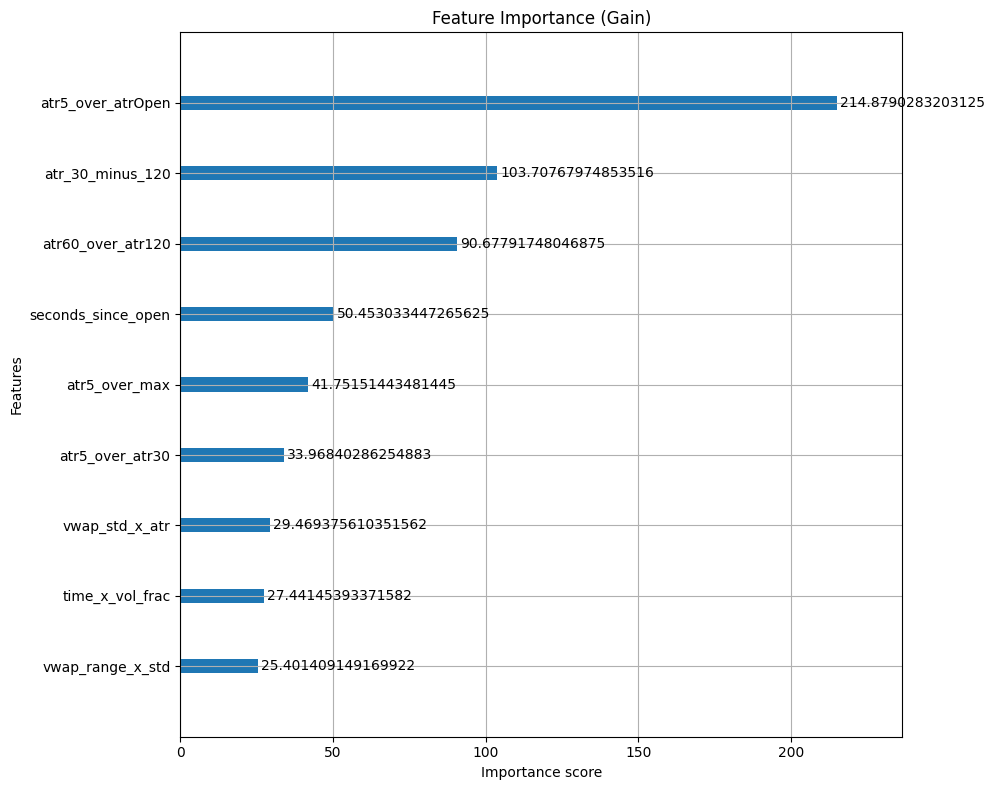


Feature Importance Ranking:
              feature  importance
1   atr5_over_atrOpen    0.347842
2    atr_30_minus_120    0.167880
6   atr60_over_atr120    0.146787
0  seconds_since_open    0.081672
7       atr5_over_max    0.067586
5     atr5_over_atr30    0.054987
3      vwap_std_x_atr    0.047704
4     time_x_vol_frac    0.044422
8    vwap_range_x_std    0.041119


In [12]:
import matplotlib.pyplot as plt

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model, ax=ax, max_num_features=20, importance_type='gain')
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# Get feature importance as dataframe
importance_df = pd.DataFrame({
    'feature': feats,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(importance_df)

In [13]:
res_df = pd.concat(res_dfs).sort_values('datetime').reset_index(drop=True)

In [14]:
res_df[feats + ['pred_prob']].corr(method='spearman')['pred_prob']

seconds_since_open    0.358118
atr5_over_atrOpen     0.634164
atr_30_minus_120      0.570123
vwap_std_x_atr        0.373399
time_x_vol_frac       0.385668
atr5_over_atr30       0.237610
atr60_over_atr120     0.511255
atr5_over_max         0.286352
vwap_range_x_std      0.220114
pred_prob             1.000000
Name: pred_prob, dtype: float64

In [15]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(res_df['labelk1'], res_df['pred_prob'])
auc_flip = roc_auc_score(res_df['labelk1'], 1 - res_df['pred_prob'])
auc, auc_flip

(0.641184463304469, 0.3588155361717854)

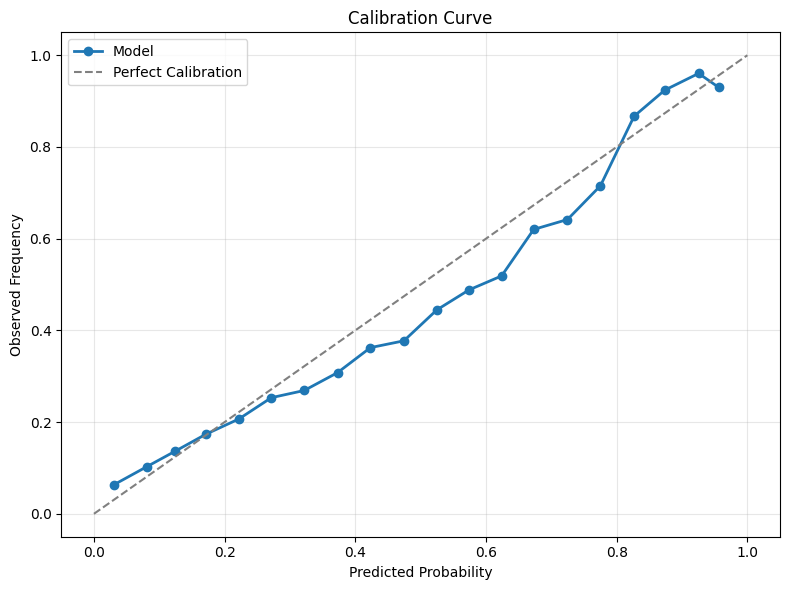

Mean predicted probability: 0.1555
Actual win rate: 0.1610


In [16]:
# Calibration curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(res_df['labelk1'], res_df['pred_prob'], n_bins=20, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Frequency')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean predicted probability: {res_df['pred_prob'].mean():.4f}")
print(f"Actual win rate: {res_df['labelk1'].mean():.4f}")

/tmp/ipykernel_19999/1471664076.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df.groupby("bin").agg(


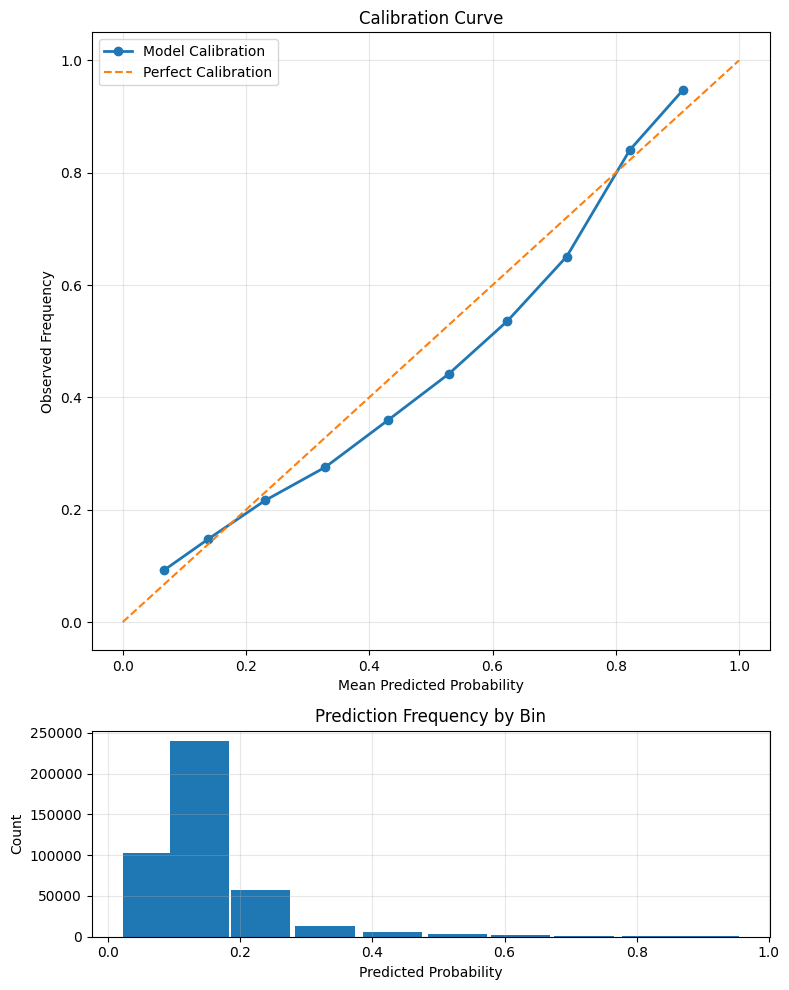

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_calibration_curve(res_df, n_bins=10):

    predicted = res_df['pred_prob']
    actual = res_df['labelk1']  # must be binary (0/1)

    df = pd.DataFrame({
        "predicted": predicted,
        "actual": actual
    })

    # Create equal-width bins
    df["bin"] = pd.cut(df["predicted"], bins=n_bins)

    # Aggregate statistics
    calibration = df.groupby("bin").agg(
        mean_predicted=("predicted", "mean"),
        mean_actual=("actual", "mean"),
        count=("actual", "size")
    ).dropna()

    # Convert bins to numeric centers for plotting
    calibration["bin_center"] = calibration["mean_predicted"]

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(8, 10),
        gridspec_kw={'height_ratios': [3, 1]}
    )

    # -------------------------
    # Calibration Curve
    # -------------------------
    ax1.plot(calibration["mean_predicted"],
             calibration["mean_actual"],
             marker='o',
             linewidth=2,
             label="Model Calibration")

    ax1.plot([0, 1], [0, 1],
             linestyle='--',
             label="Perfect Calibration")

    ax1.set_xlabel("Mean Predicted Probability")
    ax1.set_ylabel("Observed Frequency")
    ax1.set_title("Calibration Curve")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # -------------------------
    # Frequency Bars
    # -------------------------
    ax2.bar(calibration["bin_center"],
            calibration["count"],
            width=1/n_bins * 0.9)

    ax2.set_xlabel("Predicted Probability")
    ax2.set_ylabel("Count")
    ax2.set_title("Prediction Frequency by Bin")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return calibration
calibration_df = plot_calibration_curve(res_df, n_bins=10)

In [33]:
res_df.to_csv("big_movement_predictions.csv", index=False)